# ***SUPERSTORE SALES PROJECT*** 

In [72]:
# Step 1: Install the required packages
!pip install jupyter_contrib_nbextensions jupyter_nbextensions_configurator
!pip install jupyter_nbextensions_configurator

# Step 2: Install the JavaScript and CSS files
!jupyter contrib nbextension install --user

# Step 3: Enable the nbextensions configurator
!jupyter nbextensions_configurator enable --user

# Step 4: Enable specific Markdown-enhancing extensions
# These are some of the most useful extensions for Markdown
!jupyter nbextension enable toc2/main
!jupyter nbextension enable collapsible_headings/main
!jupyter nbextension enable spellchecker/main
!jupyter nbextension enable markdown_checklist/main
!jupyter nbextension enable table_beautifier/main
!jupyter nbextension enable codefolding/main

C:\Users\Irene\anaconda3\Lib\site-packages\jupyter_contrib_core\application.py:12: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Traceback (most recent call last):
  File "C:\Users\Irene\anaconda3\Lib\site-packages\jupyter_contrib_core\notebook_compat\nbextensions.py", line 6, in <module>
    from notebook.extensions import BaseExtensionApp
ModuleNotFoundError: No module named 'notebook.extensions'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "C:\Users\Irene\anaconda3\Lib\site-packages\jupyter_contrib_core\notebook_compat\nbextensions.py", line 10, in <module>
    from notebook.nbextensions import BaseNBExtensionApp
ModuleNotFoundError: No module named 'notebook.nbextensions'

During handling of the above

## **Loading the dataset & Date Fixing**

In [33]:
!pip install pandas
!pip install seaborn
!pip install numpy

In [34]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [35]:
# Read the Excel file
df = pd.read_excel('Music/sampleSuperstore.xlsx')

# Convert Excel date serial numbers to proper dates
# Excel dates are days since December 30, 1899 (for Windows Excel)
df['Order Date'] = pd.to_datetime('1899-12-30') + pd.to_timedelta(df['Order Date'], unit='D')
df['Ship Date'] = pd.to_datetime('1899-12-30') + pd.to_timedelta(df['Ship Date'], unit='D')

# Display the first few rows to verify dates were parsed correctly
print(df[['Order Date', 'Ship Date']].head())

  Order Date  Ship Date
0 2016-11-08 2016-11-11
1 2016-11-08 2016-11-11
2 2016-06-12 2016-06-16
3 2015-10-11 2015-10-18
4 2015-10-11 2015-10-18


In [36]:
df.shape

(9994, 21)

In [37]:
# Column names
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [38]:
#data types and missing value
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

In [39]:
df.describe(include='all')

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
count,9994.000000,9994,9994,9994,9994,9994,9994,9994,9994,9994,...,9994.000000,9994,9994,9994,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000
unique,NaN,5009,NaN,NaN,4,793,793,3,1,531,...,NaN,4,1862,3,17,1850,NaN,NaN,NaN,NaN
top,NaN,CA-2017-100111,NaN,NaN,Standard Class,WB-21850,William Brown,Consumer,United States,New York City,...,NaN,West,OFF-PA-10001970,Office Supplies,Binders,Staple envelope,NaN,NaN,NaN,NaN
freq,NaN,14,NaN,NaN,5968,37,37,5191,9994,915,...,NaN,3203,19,6026,1523,48,NaN,NaN,NaN,NaN
mean,4997.500000,NaN,2016-04-30 00:07:12.259355648,2016-05-03 23:06:58.571142912,NaN,NaN,NaN,NaN,NaN,NaN,...,55190.379428,NaN,NaN,NaN,NaN,NaN,229.858001,3.789574,0.156203,28.656896
min,1.000000,NaN,2014-01-03 00:00:00,2014-01-07 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,...,1040.000000,NaN,NaN,NaN,NaN,NaN,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,NaN,2015-05-23 00:00:00,2015-05-27 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,...,23223.000000,NaN,NaN,NaN,NaN,NaN,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,NaN,2016-06-26 00:00:00,2016-06-29 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,...,56430.500000,NaN,NaN,NaN,NaN,NaN,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,NaN,2017-05-14 00:00:00,2017-05-18 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,...,90008.000000,NaN,NaN,NaN,NaN,NaN,209.940000,5.000000,0.200000,29.364000
max,9994.000000,NaN,2017-12-30 00:00:00,2018-01-05 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,...,99301.000000,NaN,NaN,NaN,NaN,NaN,22638.480000,14.000000,0.800000,8399.976000


In [40]:
# Clean column names
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
)
df.columns


Index(['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode',
       'customer_id', 'customer_name', 'segment', 'country', 'city', 'state',
       'postal_code', 'region', 'product_id', 'category', 'sub-category',
       'product_name', 'sales', 'quantity', 'discount', 'profit'],
      dtype='object')

In [41]:
# Check missing values
df.isnull().sum()


row_id           0
order_id         0
order_date       0
ship_date        0
ship_mode        0
customer_id      0
customer_name    0
segment          0
country          0
city             0
state            0
postal_code      0
region           0
product_id       0
category         0
sub-category     0
product_name     0
sales            0
quantity         0
discount         0
profit           0
dtype: int64

In [42]:
# Fill missing categorical values
categorical_cols = df.select_dtypes(include='object').columns
df[categorical_cols] = df[categorical_cols].fillna("Unknown")

df.isnull().sum()


row_id           0
order_id         0
order_date       0
ship_date        0
ship_mode        0
customer_id      0
customer_name    0
segment          0
country          0
city             0
state            0
postal_code      0
region           0
product_id       0
category         0
sub-category     0
product_name     0
sales            0
quantity         0
discount         0
profit           0
dtype: int64

In [43]:
# Check duplicates
df.duplicated().sum()

# Drop duplicates
df = df.drop_duplicates()


In [44]:
# Convert date columns
date_cols = ['order_date', 'ship_date']

for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

df[date_cols].dtypes


order_date    datetime64[ns]
ship_date     datetime64[ns]
dtype: object

In [45]:
# Ensure numeric columns are correct
numeric_cols = ['sales', 'profit', 'quantity', 'discount']

df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')

df[numeric_cols].describe()


,sales,profit,quantity,discount
count,9994.000000,9994.000000,9994.000000,9994.000000
mean,229.858001,28.656896,3.789574,0.156203
std,623.245101,234.260108,2.225110,0.206452
min,0.444000,-6599.978000,1.000000,0.000000
25%,17.280000,1.728750,2.000000,0.000000
50%,54.490000,8.666500,3.000000,0.200000
75%,209.940000,29.364000,5.000000,0.200000
max,22638.480000,8399.976000,14.000000,0.800000


In [46]:
df.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,postal_code,region,product_id,category,sub-category,product_name,sales,quantity,discount,profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [47]:
# Order processing time
df['shipping_days'] = (df['ship_date'] - df['order_date']).dt.days

# Profit margin
df['profit_margin'] = np.where(
    df['sales'] > 0,
    df['profit'] / df['sales'],
    0
)

df[['shipping_days', 'profit_margin']].head()


,shipping_days,profit_margin
0,3,0.1600
1,3,0.3000
2,4,0.4700
3,7,-0.4000
4,7,0.1125


In [48]:
df.info()
df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 23 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   row_id         9994 non-null   int64         
 1   order_id       9994 non-null   object        
 2   order_date     9994 non-null   datetime64[ns]
 3   ship_date      9994 non-null   datetime64[ns]
 4   ship_mode      9994 non-null   object        
 5   customer_id    9994 non-null   object        
 6   customer_name  9994 non-null   object        
 7   segment        9994 non-null   object        
 8   country        9994 non-null   object        
 9   city           9994 non-null   object        
 10  state          9994 non-null   object        
 11  postal_code    9994 non-null   int64         
 12  region         9994 non-null   object        
 13  product_id     9994 non-null   object        
 14  category       9994 non-null   object        
 15  sub-category   9994 n

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,product_id,category,sub-category,product_name,sales,quantity,discount,profit,shipping_days,profit_margin
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,3,0.1600
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,3,0.3000
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,4,0.4700
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,7,-0.4000
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,7,0.1125


In [49]:
df.to_csv("superstore_cleaned.csv", index=False)


# **EDA and Visualizations**

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Settings
plt.style.use("default")
sns.set_context("notebook")

# Load cleaned dataset
df = pd.read_csv("superstore_cleaned.csv")

df.head()


,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,product_id,category,sub-category,product_name,sales,quantity,discount,profit,shipping_days,profit_margin
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,3,0.1600
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,3,0.3000
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,4,0.4700
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,7,-0.4000
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,7,0.1125


In [51]:
# Dataset shape
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

# Basic statistics
df.describe()


Rows: 9994
Columns: 23


,row_id,postal_code,sales,quantity,discount,profit,shipping_days,profit_margin
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896,3.958175,0.120314
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108,1.747567,0.466754
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000,0.000000,-2.750000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750,3.000000,0.075000
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500,4.000000,0.270000
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000,5.000000,0.362500
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000,7.000000,0.500000


### **Sales, Profit and Quantity Overview**

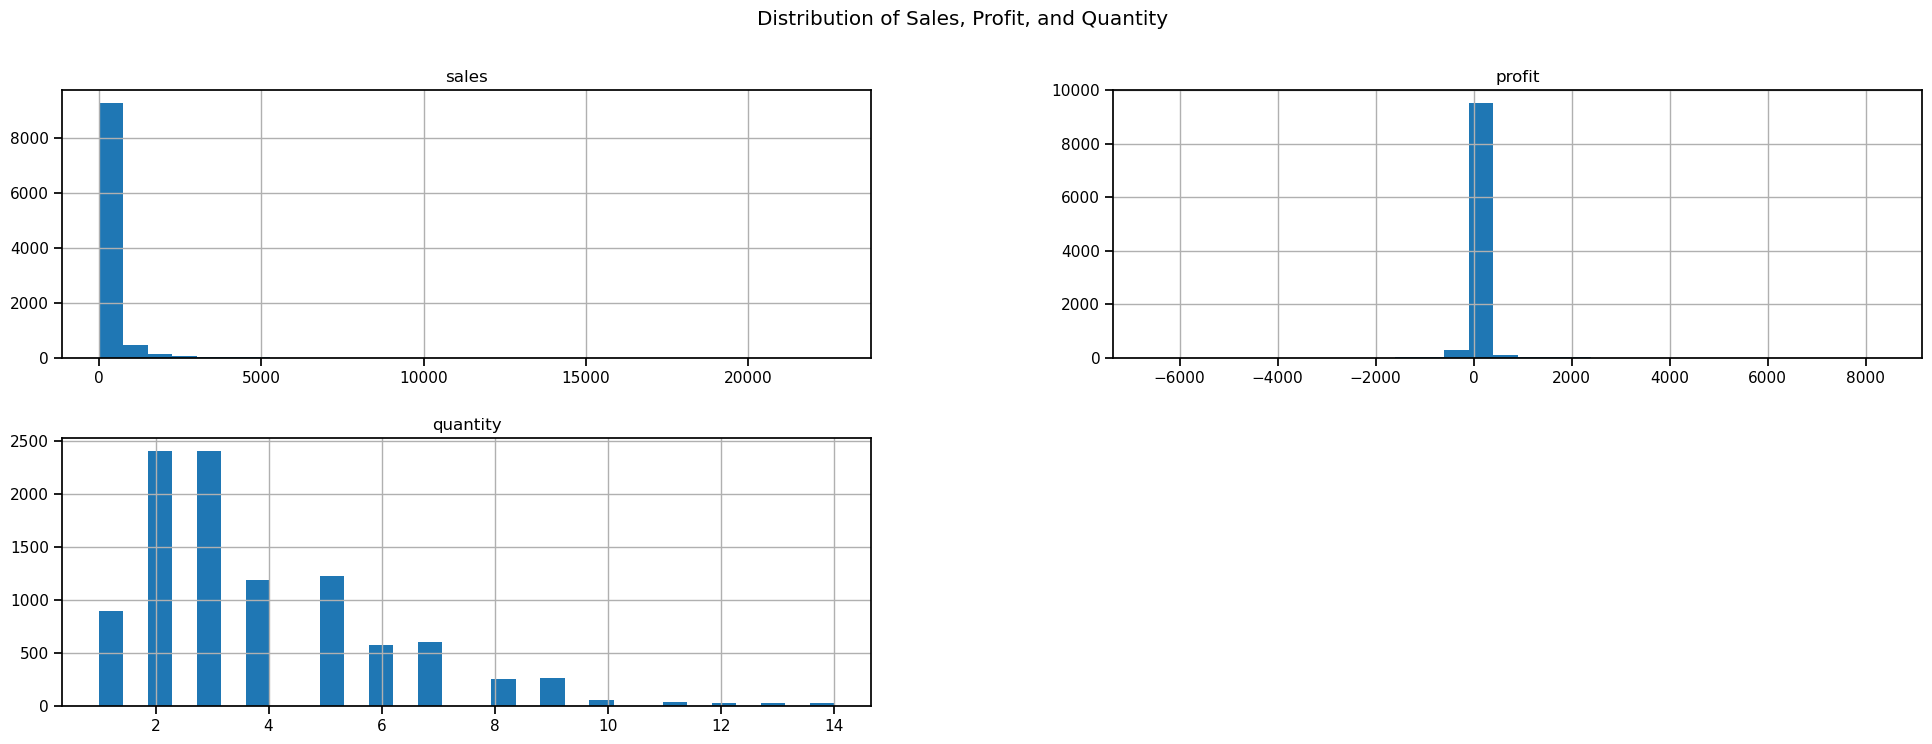

In [52]:
metrics = df[['sales', 'profit', 'quantity']]

metrics.hist(bins=30, figsize=(24,8))
plt.suptitle("Distribution of Sales, Profit, and Quantity")
plt.show()


*Insight:*

*Sales are right-skewed*

*Profit includes negative values (loss-making orders)*

### **Sales & Profit Over Time**

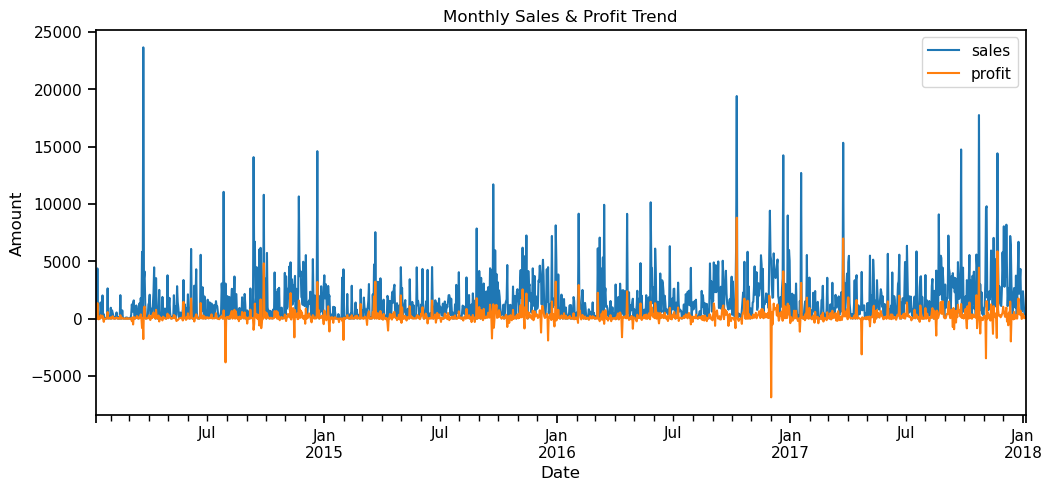

In [53]:
monthly_sales = (
    df
    .set_index(pd.to_datetime(df['ship_date']))
    .resample('D')[['sales', 'profit']]
    .sum()
)

monthly_sales.plot(figsize=(12,5))
plt.title("Monthly Sales & Profit Trend")
plt.ylabel("Amount")
plt.xlabel("Date")
plt.show()


**Insight:**

* Seasonal spikes

* Sales don’t always translate to profit

### **Category & Sub-Category Performance**

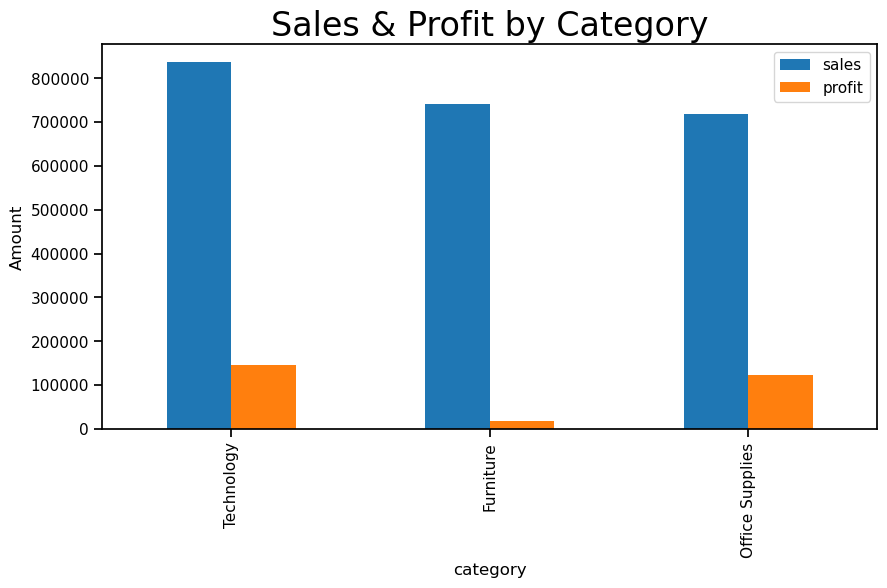

In [54]:
category_perf = (
    df.groupby('category')[['sales', 'profit']]
    .sum()
    .sort_values(by='sales', ascending=False)
)

category_perf.plot(kind='bar', figsize=(10,5))
plt.title("Sales & Profit by Category", fontsize=24)
plt.ylabel("Amount")
plt.show()


### **Sub-Category**

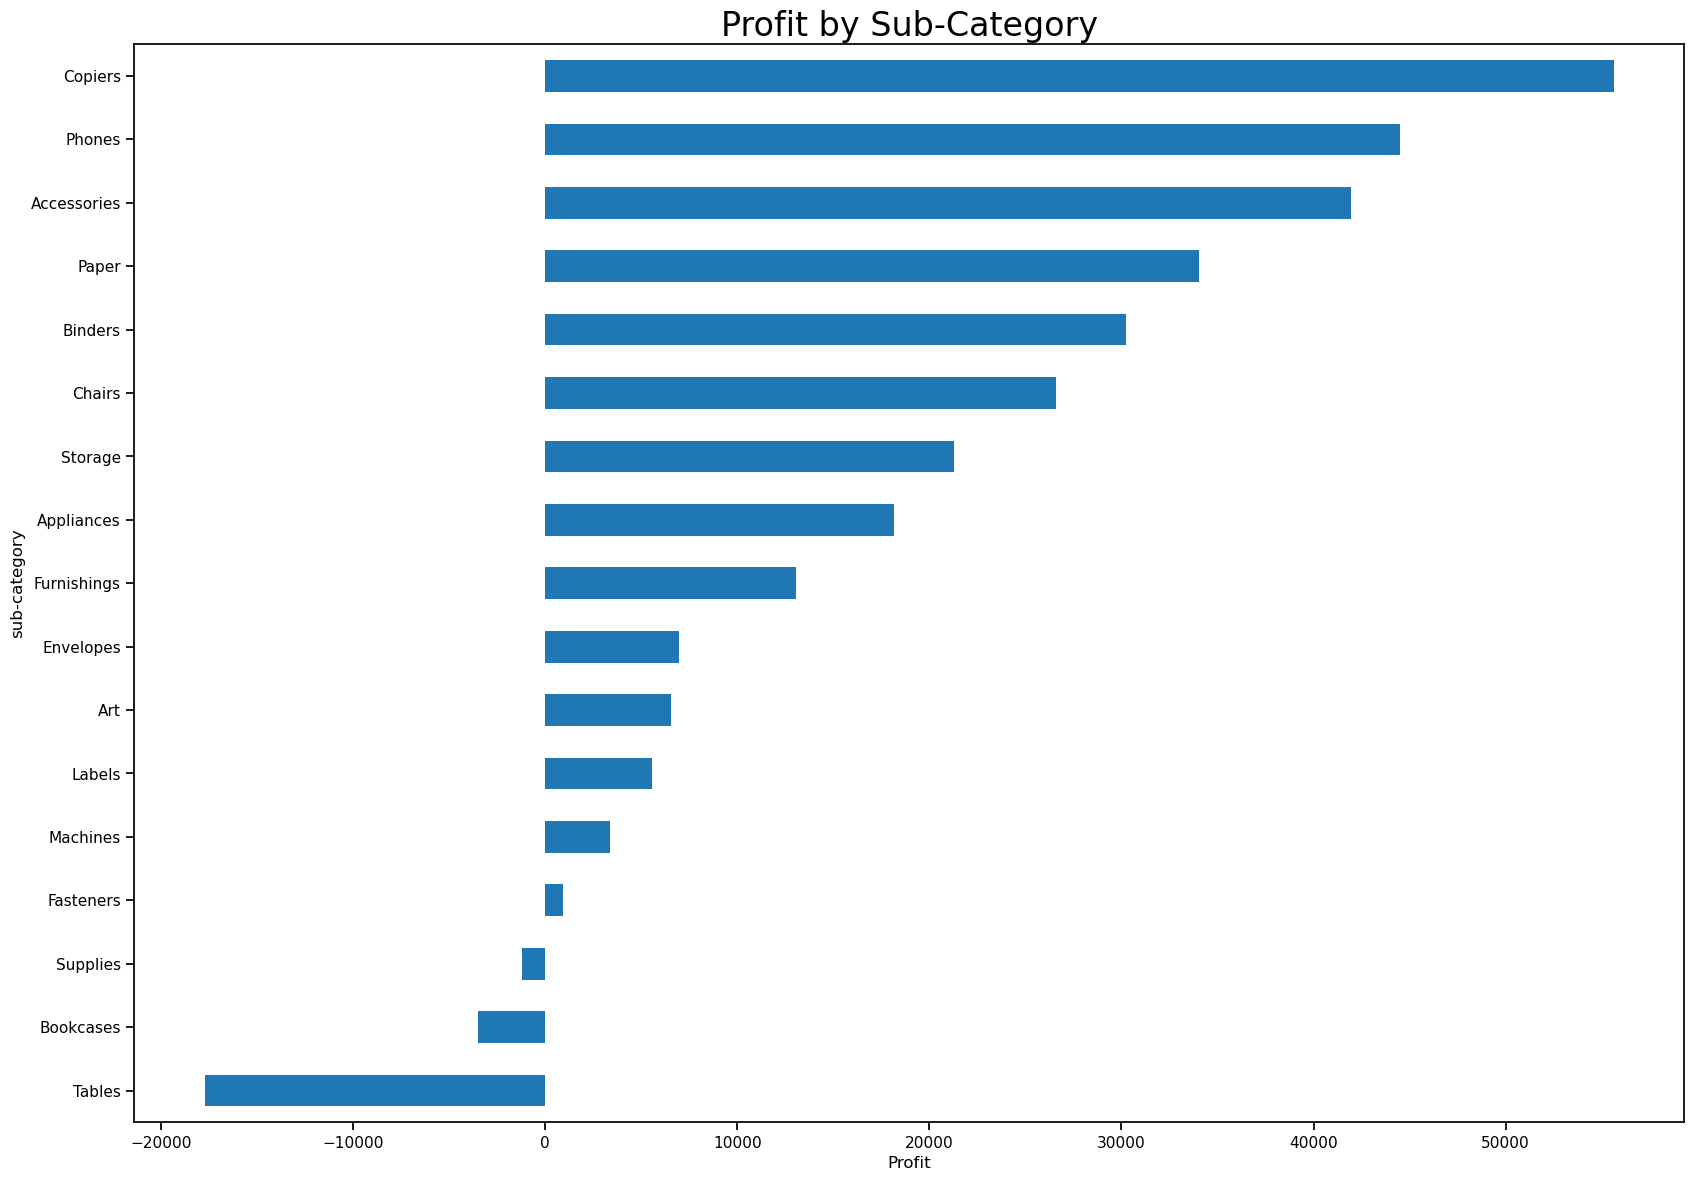

In [55]:
subcat_profit = (
    df.groupby('sub-category')['profit']
    .sum()
    .sort_values()
)

subcat_profit.plot(kind='barh', figsize=(20,14))
plt.title("Profit by Sub-Category", fontsize=24)
plt.xlabel("Profit")
plt.show()


### **Regional & State Analysis**

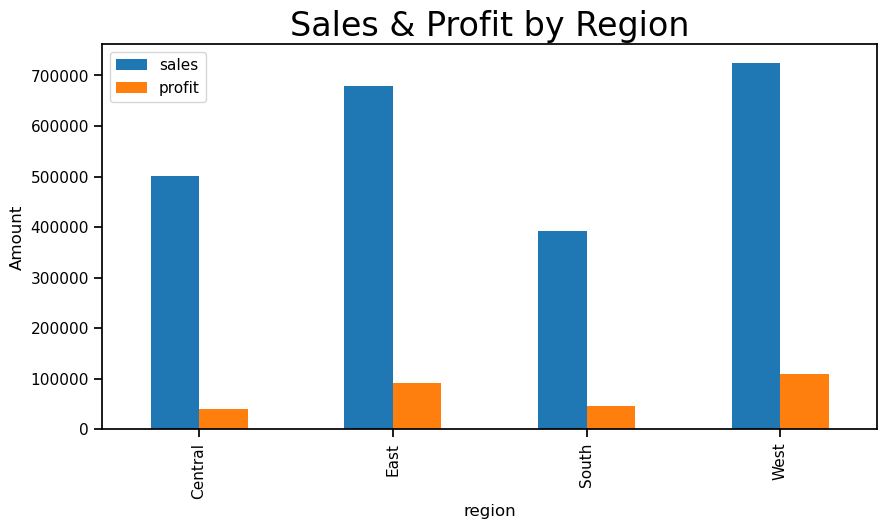

In [56]:
# Sales & Profit by region and
region_sales = (
    df.groupby('region')[['sales', 'profit']]
    .sum()
)

region_sales.plot(kind='bar', figsize=(10,5))
plt.title("Sales & Profit by Region", fontsize=24)
plt.ylabel("Amount")
plt.show()


### **Top 10 States by Sales**

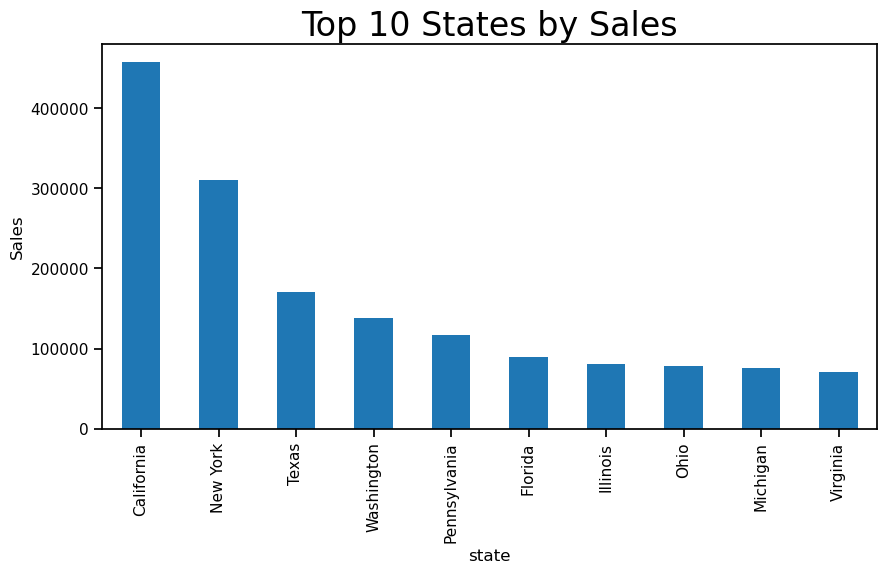

In [57]:
top_states = (
    df.groupby('state')['sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_states.plot(kind='bar', figsize=(10,5))
plt.title("Top 10 States by Sales", fontsize=24)
plt.ylabel("Sales")
plt.show()


##  Customer Segment Analysis

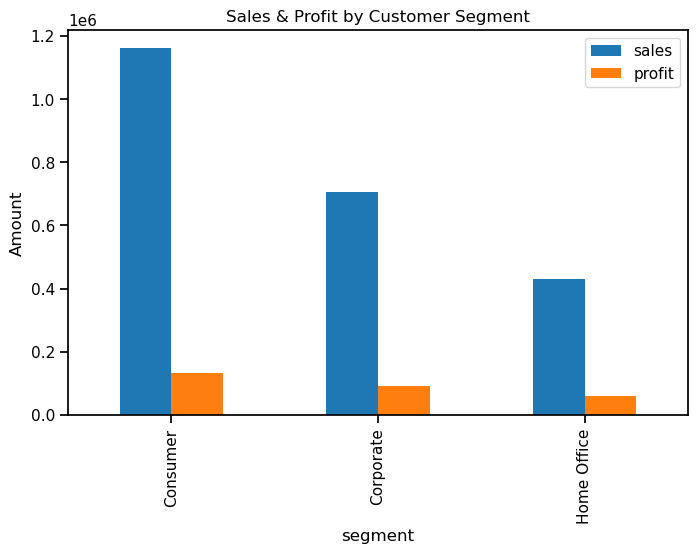

In [58]:
segment_perf = (
    df.groupby('segment')[['sales', 'profit']]
    .sum()
)

segment_perf.plot(kind='bar', figsize=(8,5))
plt.title("Sales & Profit by Customer Segment")
plt.ylabel("Amount")
plt.show()


**Insight:**

* Consumer segment drives most revenue

+ Corporate often more profitable

##  Discount vs Profit Relationship 

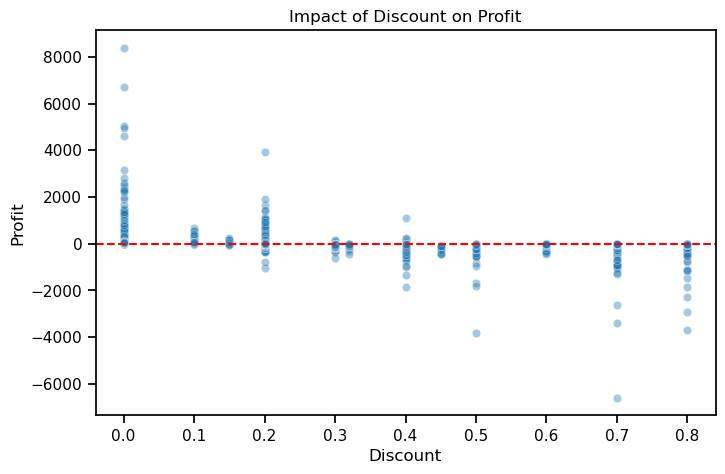

In [59]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df,
    x='discount',
    y='profit',
    alpha=0.4
)

plt.axhline(0, color='red', linestyle='--')
plt.title("Impact of Discount on Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.show()


**Insight:**

* Higher discounts strongly correlate with losses

##  Ship Mode Performance Analysis

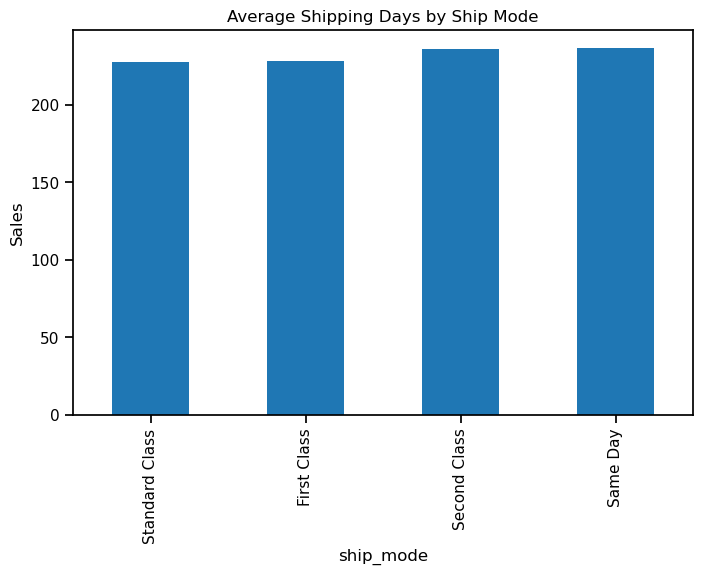

In [60]:
ship_mode_perf = (
    df.groupby('ship_mode')['sales']
    .mean()
    .sort_values()
)

ship_mode_perf.plot(kind='bar', figsize=(8,5))
plt.title("Average Shipping Days by Ship Mode")
plt.ylabel("Sales")
plt.show()


##  Correlation Heatmap

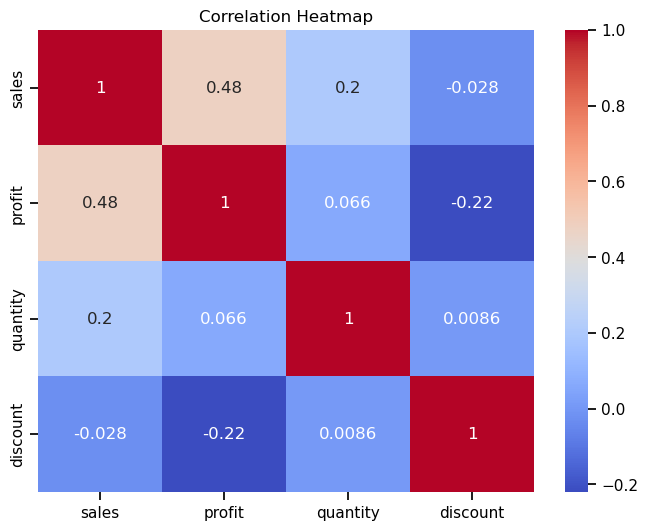

In [61]:
plt.figure(figsize=(8,6))
sns.heatmap(
    df[['sales', 'profit', 'quantity', 'discount']].corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title("Correlation Heatmap")
plt.show()


##  Top & Bottom Products (Profitability)


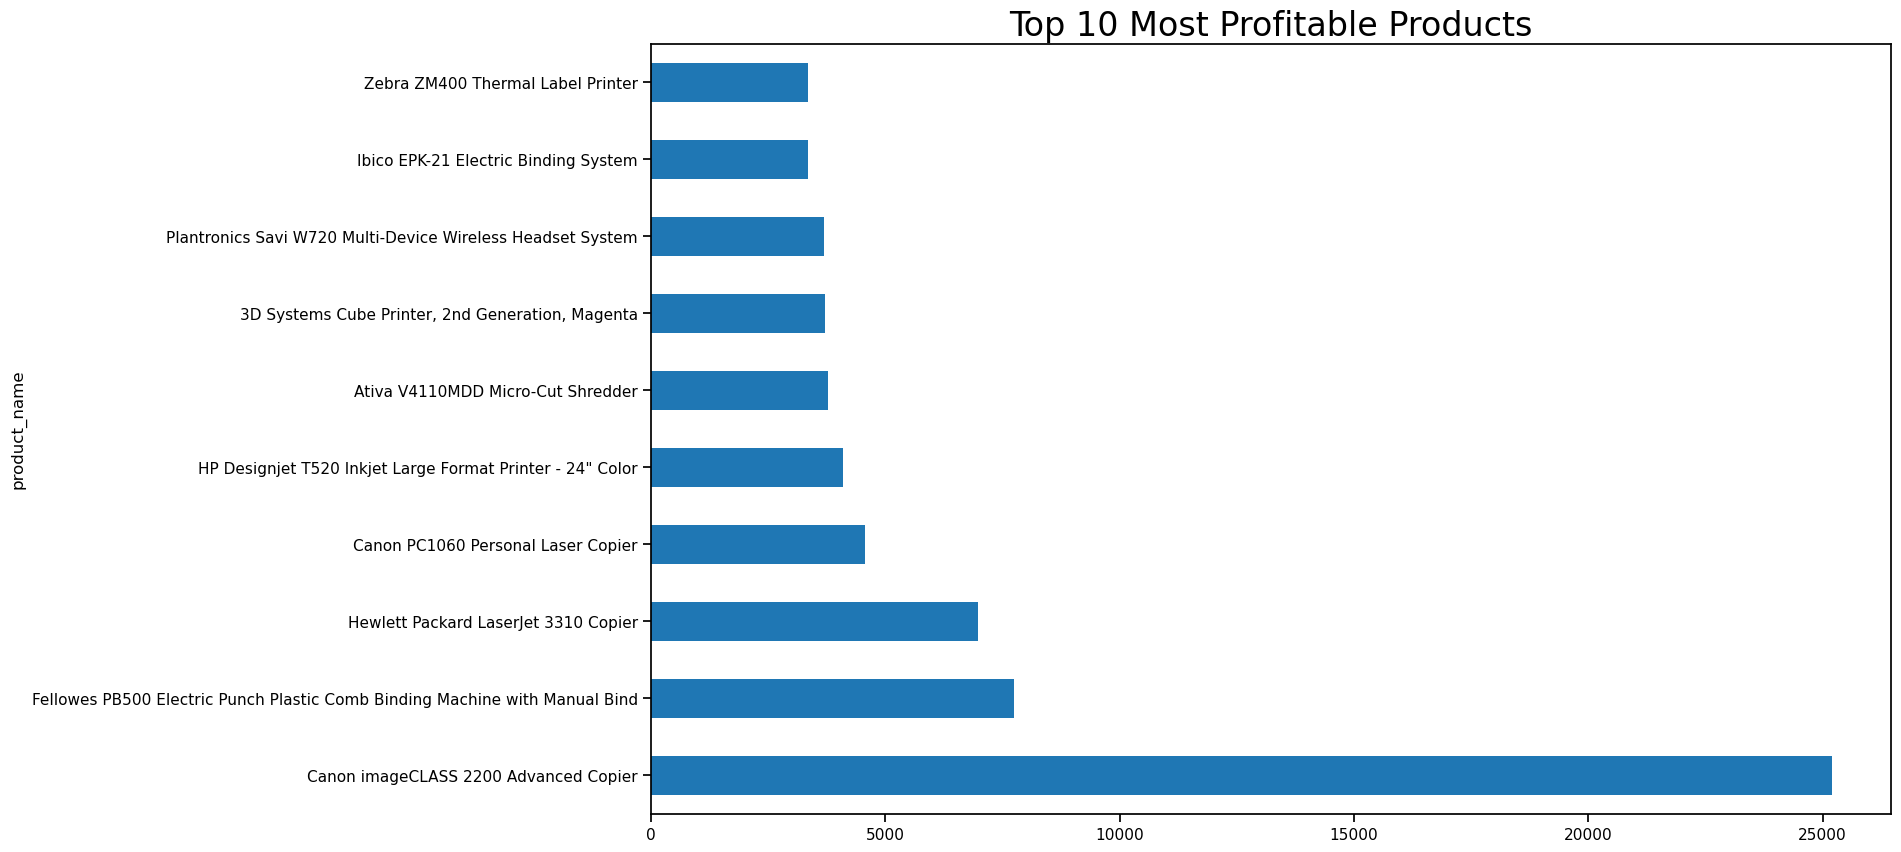

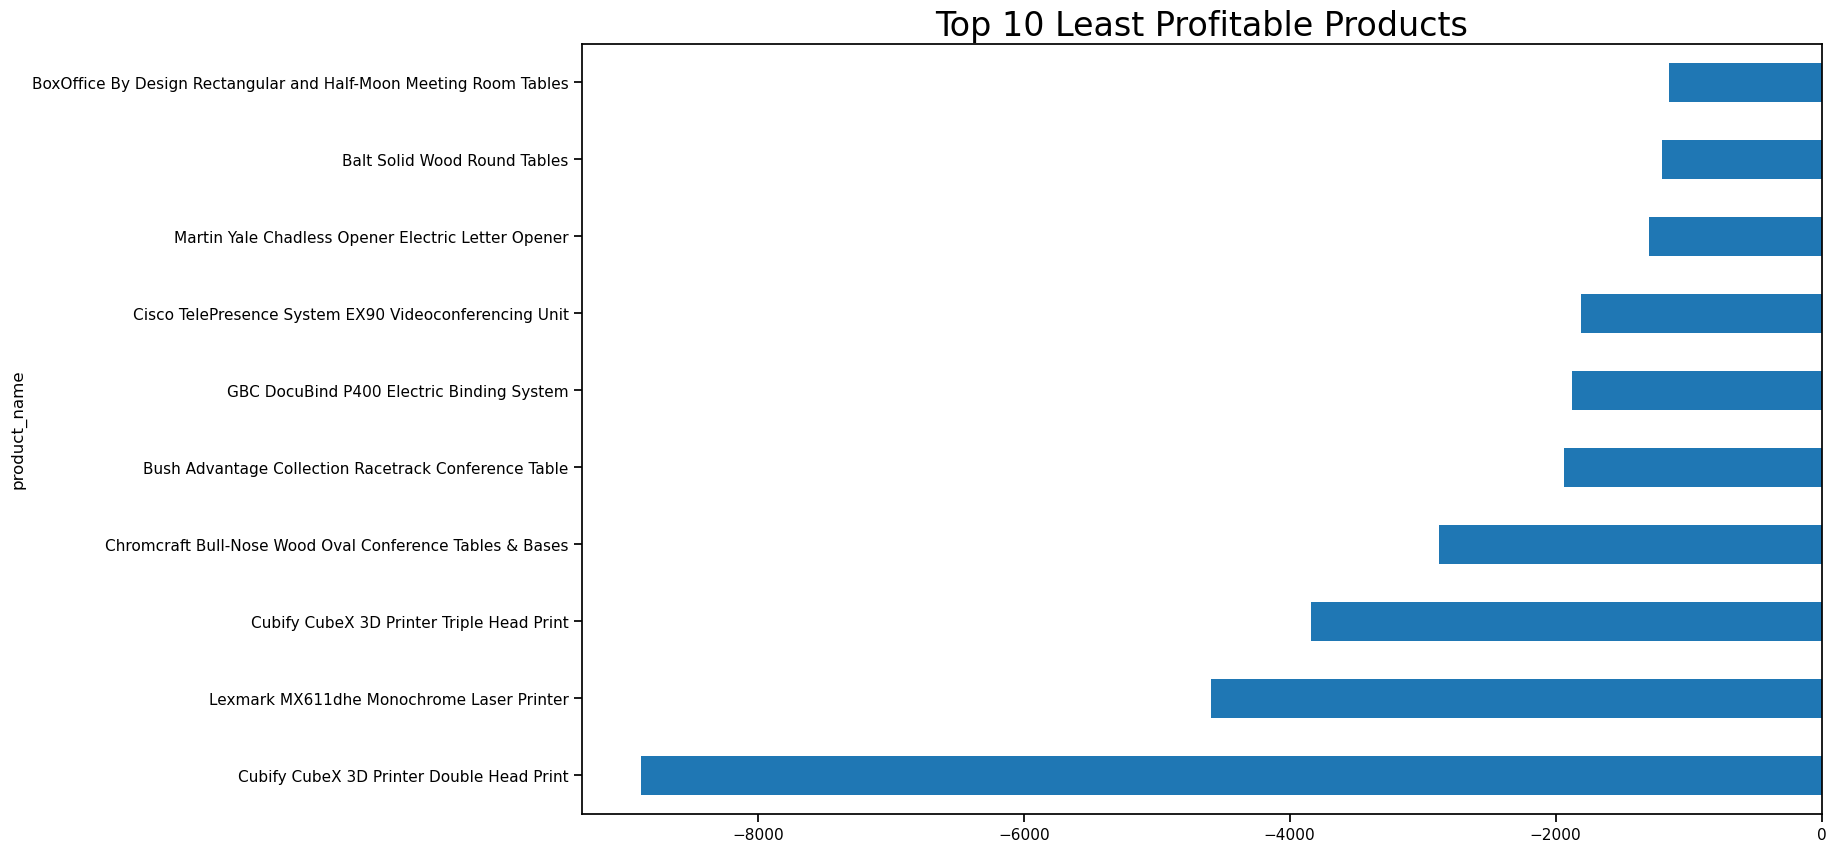

In [62]:
product_profit = (
    df.groupby('product_name')['profit']
    .sum()
)

top_products = product_profit.sort_values(ascending=False).head(10)
bottom_products = product_profit.sort_values().head(10)

top_products.plot(kind='barh', figsize=(16,10))
plt.title("Top 10 Most Profitable Products", fontsize=24)
plt.show()

bottom_products.plot(kind='barh', figsize=(16,10))
plt.title("Top 10 Least Profitable Products", fontsize=24)
plt.show()


##  Business KPIs (Dashboard Metrics)

In [63]:
total_sales = df['sales'].sum()
total_profit = df['profit'].sum()
profit_margin = total_profit / total_sales

print(f"Total Sales: ${total_sales:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")
print(f"Overall Profit Margin: {profit_margin:.2%}")


Total Sales: $2,297,200.86
Total Profit: $286,397.02
Overall Profit Margin: 12.47%


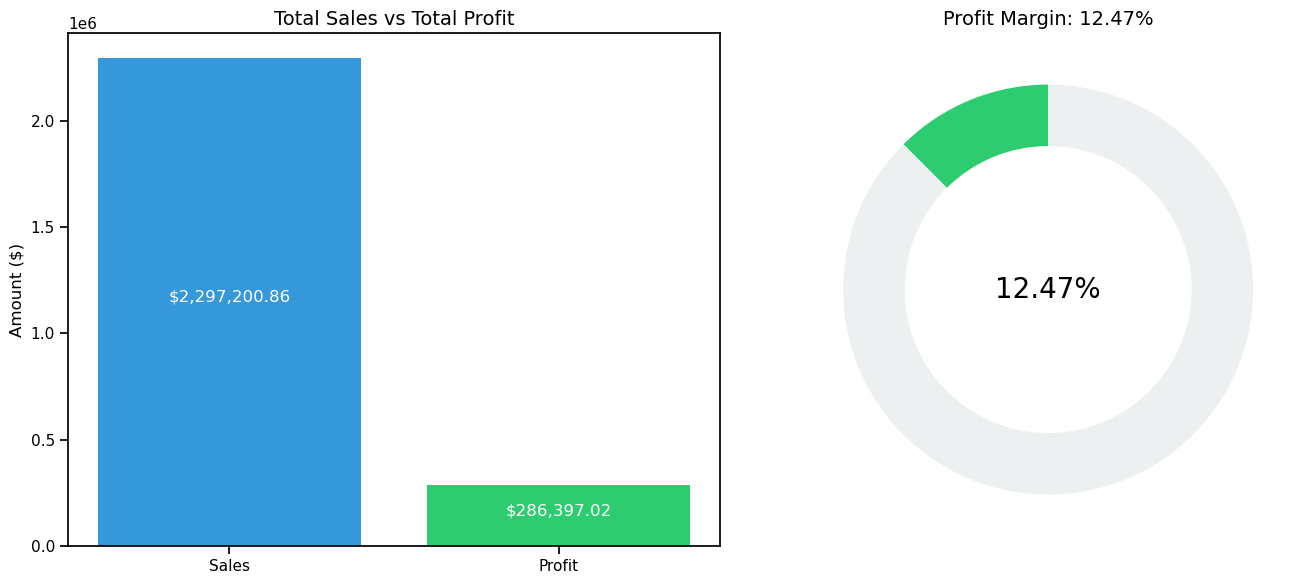

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. Sales and Profit Overview
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Sales and Profit Bar Chart
metrics = ['Sales', 'Profit']
values = [2297200.86, 286397.02]
ax[0].bar(metrics, values, color=['#3498db', '#2ecc71'])
ax[0].set_title('Total Sales vs Total Profit', fontsize=14)
ax[0].set_ylabel('Amount ($)', fontsize=12)
for i, v in enumerate(values):
    ax[0].text(i, v/2, f'${v:,.2f}', ha='center', fontsize=12, color='white')

# Profit Margin Gauge Chart (simplified as a pie chart)
labels = ['Profit', 'Cost']
sizes = [12.47, 87.53]  # Profit margin and remaining percentage
colors = ['#2ecc71', '#ecf0f1']
ax[1].pie(sizes, labels=None, colors=colors, startangle=90, wedgeprops={'width': 0.3})
ax[1].set_title('Profit Margin: 12.47%', fontsize=14)
ax[1].text(0, 0, "12.47%", ha='center', va='center', fontsize=20)

plt.tight_layout()
plt.show()